## Mlflow Demonstration using Logistic Regression Algorithm

2026/04/19 23:07:30 INFO mlflow.tracking.fluent: Experiment with name 'Iris_Experiment' does not exist. Creating a new experiment.
2026/04/19 23:07:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run wise-smelt-484 at: http://127.0.0.1:5000/#/experiments/506088561821804247/runs/84a7a8a4717c4abaa024cf7fb5248475
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/506088561821804247


2026/04/19 23:07:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run carefree-bee-395 at: http://127.0.0.1:5000/#/experiments/506088561821804247/runs/2b1ffaead3fa44df9cc361530579460a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/506088561821804247


2026/04/19 23:07:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run secretive-lark-641 at: http://127.0.0.1:5000/#/experiments/506088561821804247/runs/f7836b91d8314894a547d14a6af97b8a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/506088561821804247
🏃 View run defiant-ray-462 at: http://127.0.0.1:5000/#/experiments/506088561821804247/runs/061d7085e8754bf59606aba15b18e808
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/506088561821804247
MLflow Iris demo completed successfully


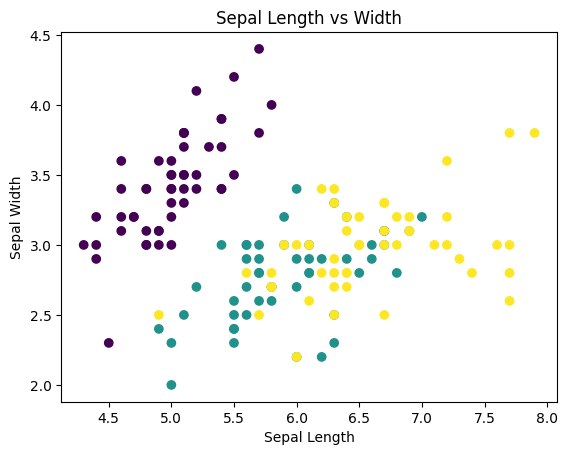

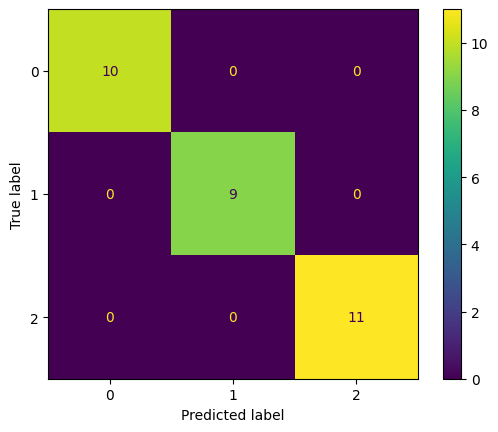

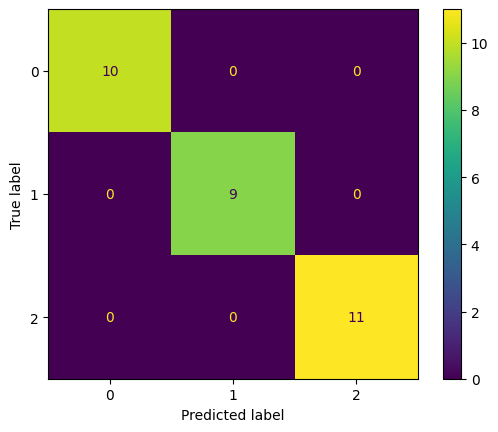

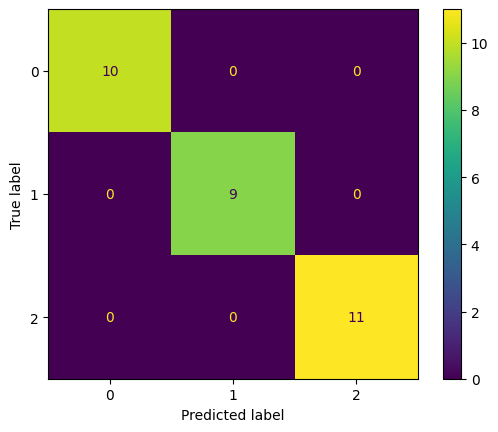

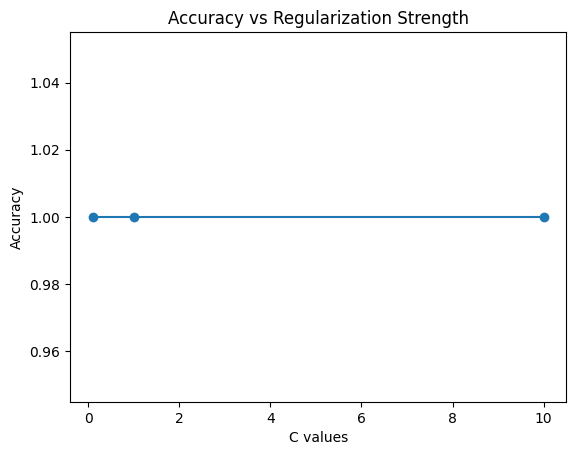

In [1]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay


# connect to tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# create experiment
mlflow.set_experiment("Iris_Experiment")


# load dataset
iris = load_iris()
X = iris.data
y = iris.target


# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# scatter plot visualization
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Width")
plt.savefig("scatter_plot.png")


# hyperparameter experiments
C_values = [0.1, 1, 10]
accuracy_results = []


for c in C_values:

    with mlflow.start_run():

        model = LogisticRegression(
            C=c,
            max_iter=200
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        accuracy = accuracy_score(y_test, preds)

        accuracy_results.append(accuracy)


        # log parameters
        mlflow.log_param("C", c)


        # log metrics
        mlflow.log_metric("accuracy", accuracy)


        # log scatter plot artifact
        mlflow.log_artifact("scatter_plot.png")


        # confusion matrix plot
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            preds
        )

        plt.savefig("confusion_matrix.png")

        mlflow.log_artifact("confusion_matrix.png")


        # save trained model
        mlflow.sklearn.log_model(
            model,
            name="iris_model"
        )


# accuracy comparison plot
plt.figure()

plt.plot(
    C_values,
    accuracy_results,
    marker="o"
)

plt.xlabel("C values")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Regularization Strength")

plt.savefig("accuracy_comparison.png")


# log comparison plot separately
with mlflow.start_run():

    mlflow.log_artifact("accuracy_comparison.png")


print("MLflow Iris demo completed successfully")

## MLflow Demo through CNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import mlflow
import mlflow.pytorch


# connect to tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# create experiment
mlflow.set_experiment("CNN_MNIST_Demo")


# dataset transform
transform = transforms.ToTensor()


# load dataset
trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)


# CNN model
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )


    def forward(self, x):

        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3


with mlflow.start_run():

    # log parameter
    mlflow.log_param("epochs", epochs)

    for epoch in range(epochs):

        running_loss = 0

        for images, labels in trainloader:

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()


        epoch_loss = running_loss / len(trainloader)

        print(f"Epoch {epoch+1}, Loss: {epoch_loss}")

        # log metric
        mlflow.log_metric("loss", epoch_loss, step=epoch)


    # log trained model
    mlflow.pytorch.log_model(
        model,
        name="cnn_model"
    )


print("Training complete")

2026/04/20 16:43:47 INFO mlflow.tracking.fluent: Experiment with name 'CNN_MNIST_Demo' does not exist. Creating a new experiment.


Epoch 1, Loss: 0.24382562906955924
Epoch 2, Loss: 0.06994131036529214
Epoch 3, Loss: 0.048130589516223794


2026/04/20 16:45:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/20 16:45:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/20 16:46:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Admin\AppData\Local\Temp\tmprkuspdu9\model\data, flavor: pytorch). Fall back to return ['torch==2

🏃 View run incongruous-wren-513 at: http://127.0.0.1:5000/#/experiments/236205428565693121/runs/8a47265c9c3940b8a044640feab51402
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/236205428565693121
Training complete
